#### Gaussian Mixture Model (GMM)

Gaussian Mixture Model (GMM) is an unsupervised machine learning algorithm used for clustering purpose.

It assumes that the dataset is made up of multiple normal or Gaussian distributions.

Instead of assigning a data point to each and every cluster, it provides us the probability that the data point belongs to that particular cluster.


Suppose a shopping mall wants to divide customers into groups based on:

Annual Income
Spending Score

Some customers may partially belong to multiple groups.


| Customer   | Cluster A | Cluster B |
| ---------- | --------- | --------- |
| Customer 1 | 90%       | 10%       |
| Customer 2 | 55%       | 45%       |


GMM handles this soft clustering very well.



| K-Means                | GMM                 |
| ---------------------- | ------------------- |
| Hard Clustering        | Soft Clustering     |
| Uses Centroid Distance | Uses Probability    |
| Circular Clusters      | Elliptical Clusters |
| Faster                 | Slightly Slower     |
| Simple                 | More Flexible       |


#### Algorithm of Gaussian Mixture Model (GMM) :----

(a.)    Initialize the values for mean, covariance and probabilities weights

(b.)    Calculate the Expectation step (E-Step)

        (i.)  Assign the probability that the data point belongs to each and every cluster

(c.)    Calculate the Maximization Step (M Step)

        (ii.)  Update the weights of mean, covariance and mixing probabilities

(d.)    Repeat the step unless and until the E-step and M-step converge.

This optimization process is called Expectation Maximization (EM) Algorithm


#### Perform an end to end machine learning project on the Malls Customers dataset using Gaussian Mixture Model


Problem Statement :------

(i) A shopping mall company wants to divide the customers based on 

        (a.)    Annual Income

        (b.)    Spending Score

(ii)    Here we will use Gaussian Mixture Model to evaluate the performance of this model.

#### Step 1: Import all the necessary libraries

In [1210]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import train_test_split
from    sklearn.preprocessing       import StandardScaler
from    sklearn.mixture             import GaussianMixture
from    sklearn.metrics             import silhouette_score

#### OBSERVATIONS:

1.  GaussianMixture  is used as it can handle soft clustering very well.

2.  It uses Expectation Maximization Algorithm that is used to optimize the GMM parameters by updating the probabilities that the data point belong to that particular cluster.

#### Step 2: Load the dataset

In [1211]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [1212]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains all the details of the customer along with their "Annual Income" and their "Spending Score".

#### Step 3: Perform the Data Exploration

In [1213]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [1214]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [1215]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [1216]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [1217]:
#### get the columns used in the dataset

print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [1218]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [1219]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each numerical column used in the dataset.

In [1220]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each categorical column used in the dataset.

#### Step 4: Perform the Data Cleaning and Feature Engineering

In [1221]:
#### To rename the column names with their proper names

df.rename(columns={"Genre"                   :   "Gender"             ,
                    "Annual Income (k$)"     :   "Annual_Income"      ,
                    "Spending Score (1-100)" :   "Spending_Score"},
                    inplace=True)

In [1222]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  All the column names have been renamed with their proper names.

In [1223]:
#### To remove the un necessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [1224]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The CustomerID column has been removed from the dataset.

In [1225]:
#### To convert all the categorical columns of 'Gender' into the numerical values

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object for Label Encoder, transform the inputs

df['Gender'] = label.fit_transform(df['Gender'])

In [1226]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  All the categorical values of Gender column have been converted into their numerical values.

In [1227]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1228]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [1229]:
#### To get the correlation for all the numerical columns in the dataset

df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the correlation between all the numerical columns used in the dataset.

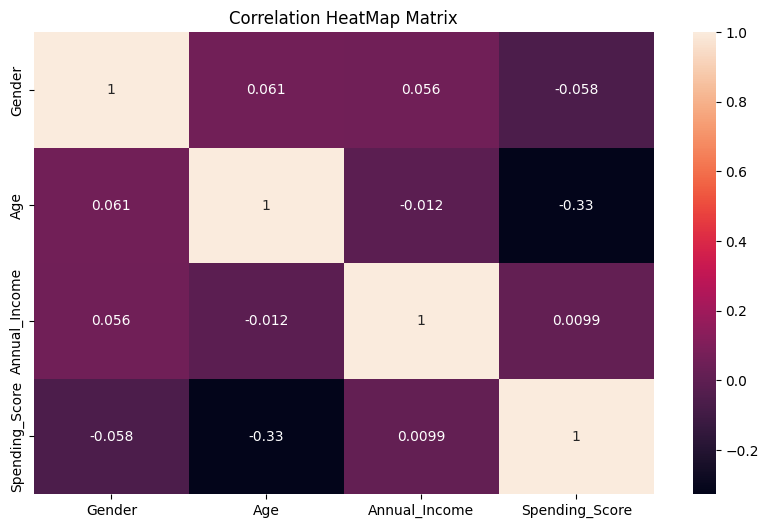

In [1230]:
#### To get the graphical representation for the correlation for all the numerical columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graphical representation depicts about the numerical correlation for all the column used in the dataset.

2.  The correlation between the 'Gender' and 'Age' is very high.

3.  The correlation between the 'Age' and 'Spending Score' is very low.

#### Step 6: Select Important Features

In [1231]:
#### Select all the important features

X = df[['Annual_Income','Spending_Score']]

In [1232]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The features that were selected for performing the clustering operation in the dataset is 

    (a.)    Annual_Income

    (b.)    Spending_Score

#### Step 7: Perform the Feature Scaling on the selected features

In [1233]:
from sklearn.preprocessing import StandardScaler

##### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [1234]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  Feature scaling standardizes all features to zero mean and unit variance.

2.  This prevents one feature from dominating due to larger scale.

#### Step 8:  Calculate the BIC score to find out the optimal number of clusters

BIC stands for Bayesian Information Criterion.

It is a score used in Gaussian Mixture Model(GMM) unsupervised learning algorithm thst is used to find out the optimal number of clusters from the model.

Lower the value of BIC ============>  better is the number of clusters formed

In [1235]:
#### Calculate the BIC Score for each cluster and store it in the list

bic_score_list = []

##### Compute the bic score for each cluster
for i in range(1,11):
    #### create an object for Gaussian Mixture Model
    gmm = GaussianMixture(
        n_components        =       i       ,
        covariance_type     =     'full'    ,
        random_state        =       42
    )

    #### Train the gmm model
    gmm.fit(X_scaled)

    #### Calculate the bic score for each cluster
    bicscore = gmm.bic(X_scaled)

    #### Append the boc score to the bic list
    bic_score_list.append(bicscore)


#### OBSERVATIONS:

1.  We have initialized an empty list for storing all the bic scores.

2.  The we have taken a for loop for considering all the clusters from 1 till 10.

    (a.)    for each cluster , we have initialized  an object for GaussianMixture model that has the parameters as follows :----

        (i.)    n_clusters ===============>  Total clusters to be considered

        (ii.)   covariance type = 'full' ===>  It allows the clusters to have its own covariance matrix and be flexible

        (iii.)  random_state = 42 ========>  It should be reproducibility

    (b.)  For each cluster, the gmm model should be trained.

    (c.)  After getting trained, each gmm model produces its own bic score.

    (d.)  All the bic score of every cluster gets appended into the empty list.

In [1236]:
bic_score_list

[np.float64(1161.622799154839),
 np.float64(1153.9046550338344),
 np.float64(1151.718274341355),
 np.float64(1103.7901488005336),
 np.float64(1058.6522524191894),
 np.float64(1074.6828066321045),
 np.float64(1087.328517453244),
 np.float64(1102.3707011755782),
 np.float64(1106.8058256120178),
 np.float64(1127.618188884996)]

#### OBSERVATIONS:

1.  Each cluster produces its own bic score that gets appended into the empty list.

#### Step 9: Plot the BIC Score for each cluster

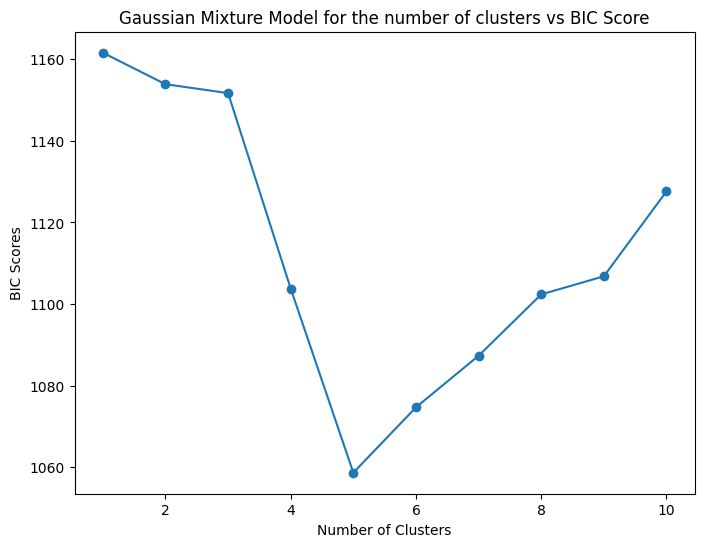

In [1237]:
plt.figure(figsize=(8,6))

#### plot the bic score for each cluster
plt.plot(range(1,11), bic_score_list, marker='o')

#### give the title of the graph
plt.title("Gaussian Mixture Model for the number of clusters vs BIC Score")

#### give the x axis of the graph
plt.xlabel("Number of Clusters")

#### give the y axis of the graph
plt.ylabel("BIC Scores")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the Gaussian Mixture Model (GMM) for the number of clusters vs BIC Score on the Mall Customers dataset.

2.  The above graph represents the bic score for each and every cluster.

3.  As Lower the BIC Score =  better is the number of clusters, so

    the optimal number of clusters to be considered  for this dataset is 5

3. This is because the lowest BIC Score occurs at (k = 5) cluster.

#### Step 10: Train Final GMM Model

In [1238]:
#### Create an object for Gaussian Mixture Model

gmm = GaussianMixture(
    n_components        =       5       ,
    covariance_type     =       'full'  ,
    random_state        =       42
)

In [1239]:
#### Train the Gaussian Mixture Model

gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

#### OBSERVATIONS:

1.  Initially the object for Gaussian Mixture Model (GMM) is created with the ollowing parameters :----

    (a.)    n_components = 5 ===============>  Total number of clusters

    (b.)    covariance_type = 'full' ========>  Each cluster to have its own covariance matrix

    (c.)    random_state = 42 ===============> ensures its own reproducibility

#### Step 11: Predict the Model

In [1240]:
Y_pred = gmm.predict(X_scaled)

In [1241]:
Y_pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

#### OBSERVATIONS:

1.  There are a total of five clusters formed.

    (a.)    Cluster 0

    (b.)    Cluster 1

    (c.)    Cluster 2

    (d.)    Cluster 3

    (e.)    Cluster 4

#### Step 12: Add the Cluster Label to the dataset

In [1242]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [1243]:
#### Add the Cluster Label to the dataset

df['Cluster'] = Y_pred

In [1244]:
#### Display the revised dataset with the cluster label

df.head()

,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


#### OBSERVATIONS:

1.  The Cluster label has been added into the dataset.

#### Step 13: Visualize the Clusters

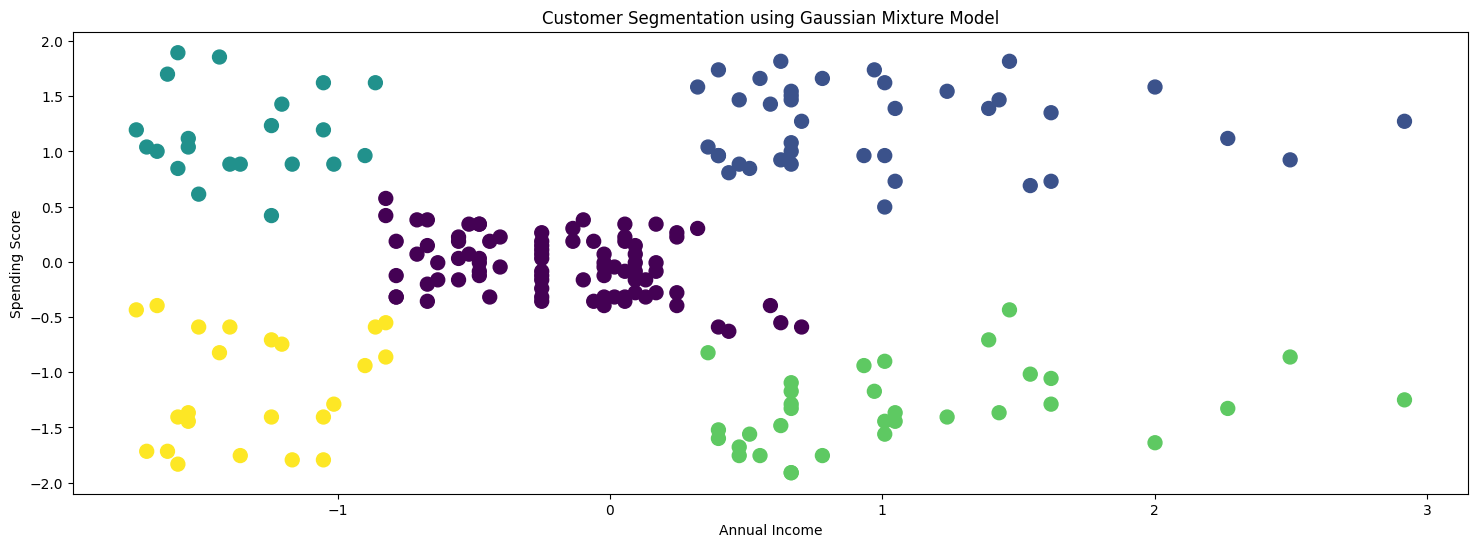

In [1245]:
plt.figure(figsize=(18,6))

plt.scatter(
    X_scaled[:,0]                                            ,
    X_scaled[:,1]                                            ,
    c                   =      Y_pred                        ,
    cmap                =    'viridis'                       ,
    s                   =       100
)

#### set the title of the graph
plt.title("Customer Segmentation using Gaussian Mixture Model")

#### set the x-axis of the graph
plt.xlabel("Annual Income")

#### set the y-axis of the graph
plt.ylabel("Spending Score")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  In the above graph, there are a total of five clusters formed in the dataset.

2.  They are as follows:-----

    (a.)   Cluster 0 =======================>     Customer with low annual income and low spending score.

    (b.)   Cluster 1 =======================>     Customer with high annual income and low spending score.

    (c.)   Cluster 2 =======================>     Customer with medium annual income and medium spending score.

    (d.)   Cluster 3 =======================>     Customer with low annual income and high spending score.

    (e.)   Cluster 3 =======================>     Customer with high annual income and high spending score

In [1246]:
#### Analyzing the clusters centers
df.head()

,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


In [1247]:
df.groupby("Gender")[["Annual_Income","Spending_Score"]].mean()

,Annual_Income,Spending_Score
Gender,,
0,59.250000,51.526786
1,62.227273,48.511364


#### OBSERVATIONS:

1.  From the above table, we come to the conclusion that

    (a.)    The Annual Income of  the Male Customers is much higher than the Female.

    (b.)    The spending score of the Female Customers is much higher than the male customers.

#### Step 14: Compute the Cluster Probability

In [1248]:
#### Compute the cluster probabilities

probabilities = gmm.predict_proba(X_scaled)

In [1249]:
probabilities[:5]

array([[1.57689698e-05, 1.88009163e-08, 9.52031247e-04, 5.20013085e-08,
        9.99032129e-01],
       [1.62776204e-05, 1.89596786e-04, 9.99790184e-01, 4.21013390e-23,
        3.94154449e-06],
       [2.21339374e-19, 9.52615737e-19, 1.22549539e-12, 1.86223280e-04,
        9.99813777e-01],
       [1.05444778e-04, 1.80087695e-04, 9.99693745e-01, 3.79390067e-21,
        2.07229768e-05],
       [6.47301428e-05, 3.84273231e-08, 1.55669540e-03, 4.75722704e-08,
        9.98378488e-01]])

#### OBSERVATIONS:

1.  As Gaussian Mixture Model depicts about the probabilities of each and every data point belonging to the cluster, here using gmm object, we can get the probabilities of each datav point belonging to the cluster.

#### Step 15: Evaluate the Quality of the cluster

In [1250]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, Y_pred)

print("Silhouette Score of the cluster is:", score)

Silhouette Score of the cluster is: 0.5536892843811245


#### Silhouette Scoring Interpretation:-------

 | Score       | Meaning              |
 | ----------- | -------------------- |
 | < 0.25      | Poor clustering      |
 | 0.25 – 0.50 | Average clustering   |
 | 0.50 – 0.70 | Good clustering      |
 | > 0.70      | Excellent clustering |

 1. The silhouette score of the cluster model is 0.55 which is a good clustering model.